In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [21]:
df = pd.read_csv('bcw_data.csv')

In [22]:
df = df.drop(columns=['id'])
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [23]:
print("Valeurs manquantes par colonne :\n", df.isnull().sum().sum())

Valeurs manquantes par colonne :
 0


In [24]:
print("\nDistribution des diagnostics :")
print(df['diagnosis'].value_counts(normalize=True))


Distribution des diagnostics :
diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


In [25]:
sns.set_theme(style="whitegrid")

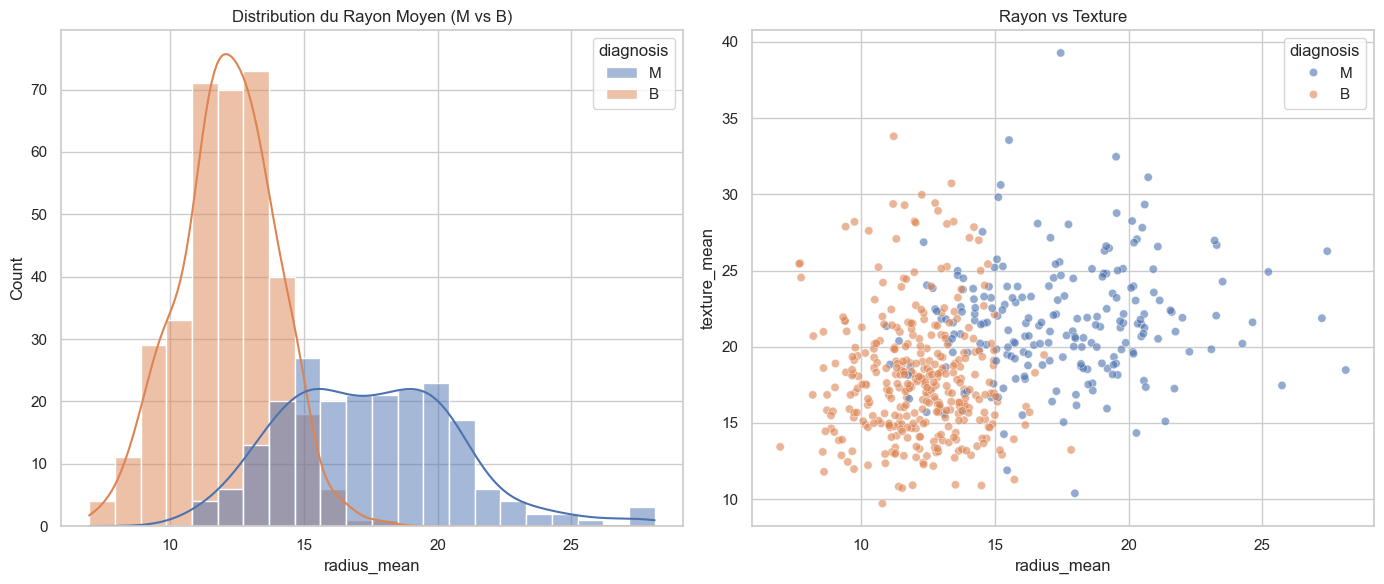

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(data=df, x='radius_mean', hue='diagnosis', kde=True, ax=ax[0])
ax[0].set_title('Distribution du Rayon Moyen (M vs B)')

sns.scatterplot(data=df, x='radius_mean', y='texture_mean', hue='diagnosis', alpha=0.6, ax=ax[1])
ax[1].set_title('Rayon vs Texture')

plt.tight_layout()
plt.show()

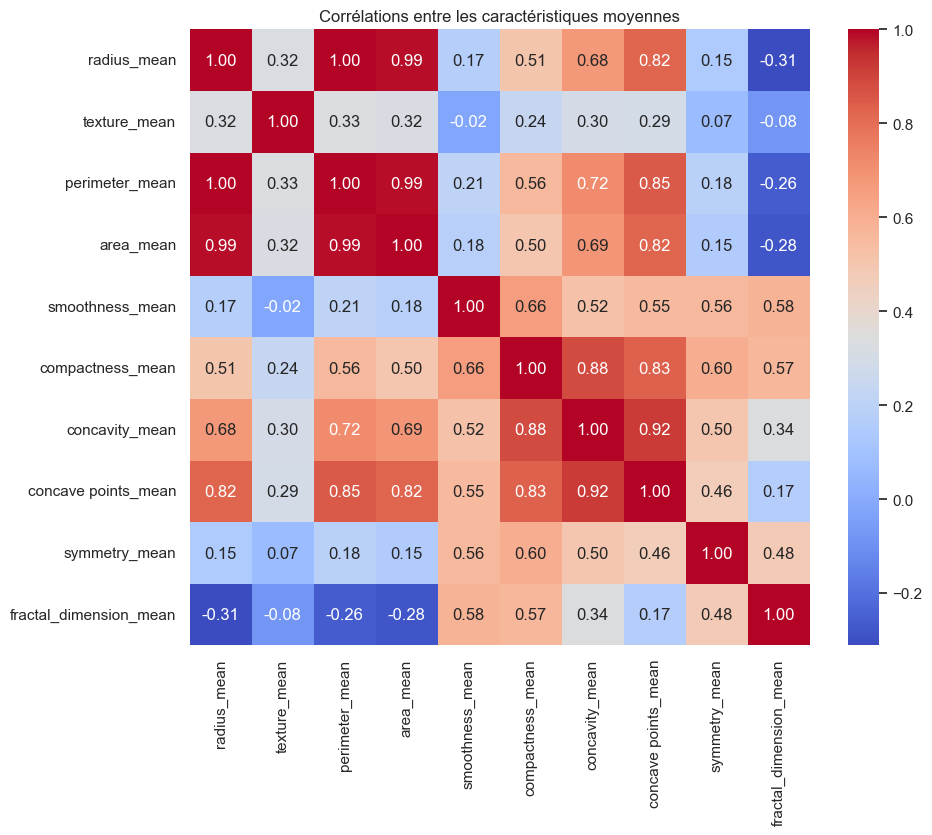

In [27]:
plt.figure(figsize=(10, 8))
mean_cols = [col for col in df.columns if 'mean' in col]
corr = df[mean_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Corrélations entre les caractéristiques moyennes')
plt.show()

In [28]:
features = df.drop(columns=['diagnosis'])
target = df['diagnosis']

In [29]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [30]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)

In [31]:
df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
df_pca['diagnosis'] = target.values

<Axes: xlabel='PC1', ylabel='PC2'>

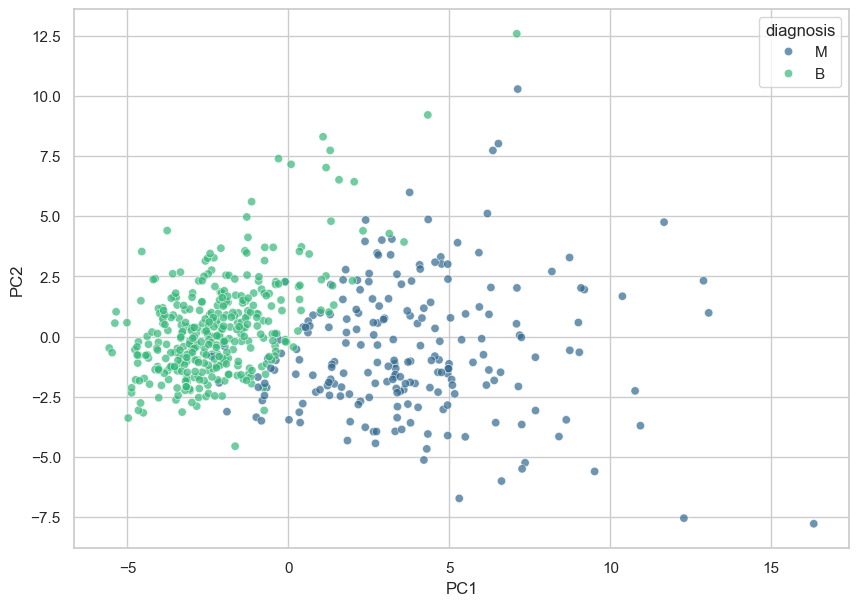

In [32]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='diagnosis', 
    palette='viridis',
    data=df_pca,
    alpha=0.7
)

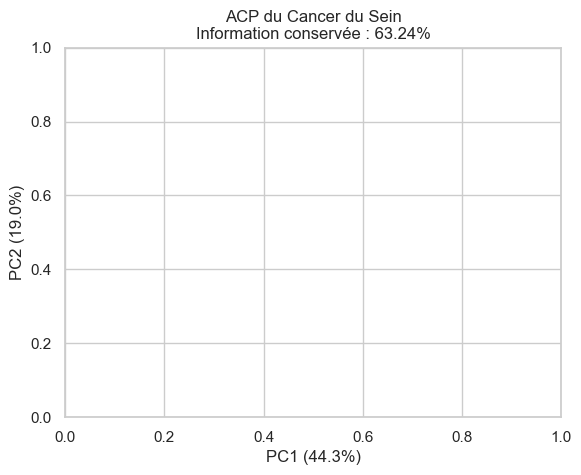

Les deux premières composantes expliquent 63.24% de la variance totale.


In [33]:
var_expl = pca.explained_variance_ratio_
plt.title(f'ACP du Cancer du Sein\nInformation conservée : {sum(var_expl)*100:.2f}%')
plt.xlabel(f'PC1 ({var_expl[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({var_expl[1]*100:.1f}%)')
plt.show()

print(f"Les deux premières composantes expliquent {sum(var_expl)*100:.2f}% de la variance totale.")

In [34]:
loadings = pd.Series(pca.components_[0], index=features.columns)
top_loadings = loadings.abs().sort_values(ascending=False).head(5)

In [35]:
print("Variables contribuant le plus à l'axe PC1 (la séparation principale) :")
print(top_loadings)

Variables contribuant le plus à l'axe PC1 (la séparation principale) :
concave points_mean     0.260854
concavity_mean          0.258400
concave points_worst    0.250886
compactness_mean        0.239285
perimeter_worst         0.236640
dtype: float64


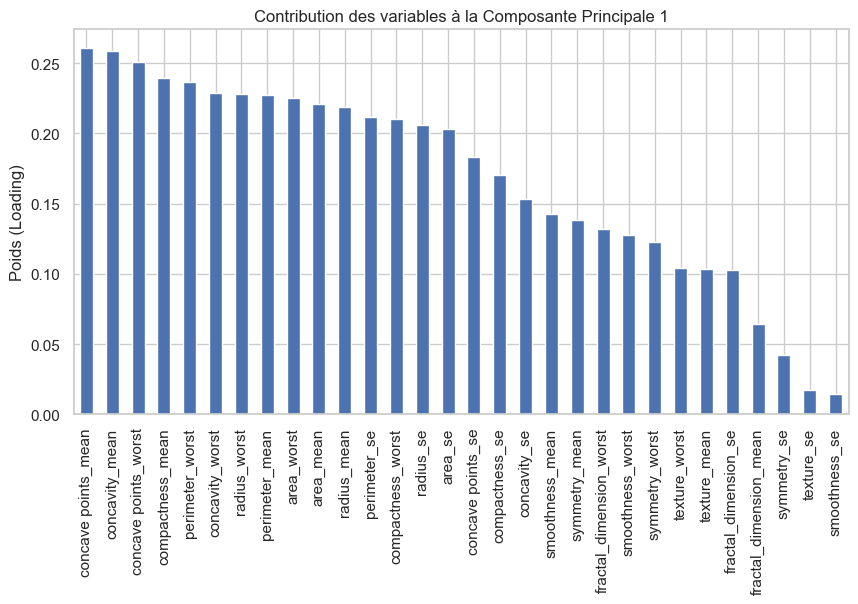

In [36]:
plt.figure(figsize=(10, 5))
loadings.sort_values(ascending=False).plot(kind='bar')
plt.title('Contribution des variables à la Composante Principale 1')
plt.ylabel('Poids (Loading)')
plt.show()